# 3.a. Recourse Dataset + Level 1: Prediction Fairness

**Author:** Matteo

Integrates with the team's pipeline:
  - Reads `.npy` splits from `data/processed/` (output of 1_Preprocessing.ipynb)
  - Reads model artifacts from `data/models/RF/` and `data/models/XGBoost/`
    (output of 2_Random_Forest.ipynb and 2_XGboost.ipynb)
  - Reads counterfactual setup from utils.py (reuses Kamila's DiCE functions)
  - Saves results to `data/fairness/`

## 0. Setup — install dependencies and load utils

In [1]:
import os
import subprocess, sys

# Install missing packages if needed (works both locally and on Colab)
subprocess.run([sys.executable, "-m", "pip", "install", "dice-ml", "xgboost", "-q"])


CompletedProcess(args=['c:\\Users\\kamil\\Desktop_new\\Local\\Universidad\\H512 Current Trends\\infoh512-project\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'dice-ml', 'xgboost', '-q'], returncode=0)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml

import utils
from utils import (
    ScaledModelWrapper, load_artifacts, load_raw_with_split,
    build_recourse_dataset, get_project_paths,
    PROTECTED_ATTRIBUTES, SEED_DICE,
)

# Auto-detects Colab vs local VSCode and returns the correct paths
PATHS = get_project_paths()

print("Project paths:")
for k, v in PATHS.items():
    print(f"  {k}: {v}")

THRESHOLD = 0.20
N_CF      = 3


Project paths:
  BASE: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project
  DATA: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
  RF: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF
  XGBoost: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost
  FAIRNESS: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\fairness


## 1. Load data (readable demographics) and model artifacts

In [3]:
df_raw, df_encoded, feature_cols = load_raw_with_split()
print(f"Dataset: {df_raw.shape[0]} employees, {len(feature_cols)} features")
print(f"True attrition rate: {df_raw['Attrition'].mean():.1%}")

Dataset: 1470 employees, 30 features
True attrition rate: 16.1%


In [4]:
rf  = load_artifacts(PATHS["RF"])
xgb = load_artifacts(PATHS["XGBoost"])
feature_names = rf["feature_names"]

rf_wrapper  = ScaledModelWrapper(rf["model"],  rf["scaler"],  feature_names)
xgb_wrapper = ScaledModelWrapper(xgb["model"], xgb["scaler"], feature_names)
print("Models loaded successfully.")

Models loaded successfully.


## 2. Build DiCE explainers (reusing the team's exact configuration)

In [5]:
dice_df = df_encoded[feature_names].astype("float64").copy()
dice_df["Attrition"] = df_encoded["Attrition"].values

dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=list(feature_names),
    outcome_name="Attrition",
)
dice_rf  = dice_ml.Model(model=rf_wrapper,  backend="sklearn", model_type="classifier")
dice_xgb = dice_ml.Model(model=xgb_wrapper, backend="sklearn", model_type="classifier")
exp_rf  = dice_ml.Dice(dice_data, dice_rf,  method="random")
exp_xgb = dice_ml.Dice(dice_data, dice_xgb, method="random")
print("DiCE explainers ready.")

DiCE explainers ready.


## 3. Generate recourse dataset on ALL at-risk employees

⚠️ This is the slow step (~5-10 min). Results are checkpointed every 25
employees so a crash never loses all progress.

In [6]:
recourse_rf = build_recourse_dataset(
    exp_rf, rf_wrapper, df_encoded, df_raw, feature_names,
    le_dict=rf["label_encoders"], n_cf=N_CF, seed=SEED_DICE,
    threshold=THRESHOLD,
    checkpoint_path=os.path.join(PATHS["FAIRNESS"], "recourse_RF.csv"),
)

Employees flagged at-risk (proba >= 0.2): 281


100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


  processed 25 / 281


100%|██████████| 1/1 [01:18<00:00, 78.38s/it]


  processed 50 / 281


...

  processed 250 / 281


100%|██████████| 1/1 [00:00<00:00,  1.39it/s]


  processed 275 / 281


100%|██████████| 1/1 [00:00<00:00,  1.10it/s]

Saved -> c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\fairness\recourse_RF.csv


In [7]:
recourse_xgb = build_recourse_dataset(
    exp_xgb, xgb_wrapper, df_encoded, df_raw, feature_names,
    le_dict=xgb["label_encoders"], n_cf=N_CF, seed=SEED_DICE,
    threshold=THRESHOLD,
    checkpoint_path=os.path.join(PATHS["FAIRNESS"], "recourse_XGB.csv"),
)

print(f"\nDone. RF: {len(recourse_rf)} employees | XGB: {len(recourse_xgb)} employees")
recourse_rf.head()

Employees flagged at-risk (proba >= 0.2): 227


100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


  processed 25 / 227


100%|██████████| 1/1 [00:00<00:00,  2.44it/s]


  processed 50 / 227


...

100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


  processed 225 / 227


100%|██████████| 1/1 [00:00<00:00,  1.73it/s]

Saved -> c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\fairness\recourse_XGB.csv

Done. RF: 281 employees | XGB: 227 employees


,emp_id,Gender,AgeGroup,Age,MaritalStatus,Department,true_attrition,predicted_risk,n_cf_found,recourse_found,L1_cost,changed_feats
0,0,Female,Senior,41,Single,Sales,1,76.0,3,True,1.1153,JobRole;StockOptionLevel;TrainingTimesLastYear...
1,2,Male,Senior,37,Single,Research & Development,1,43.0,3,True,0.8125,BusinessTravel;JobInvolvement;JobRole
2,3,Female,Young,33,Married,Research & Development,0,27.5,3,True,0.5994,DistanceFromHome;JobLevel;JobRole;Relationship...
3,14,Male,Young,28,Single,Research & Development,1,87.5,3,True,0.9092,BusinessTravel;JobLevel;MonthlyIncome;OverTime...
4,17,Male,Young,22,Divorced,Research & Development,0,36.5,3,True,0.3722,TrainingTimesLastYear;WorkLifeBalance


## 4. Level 1 — Prediction Fairness

Three group-fairness notions (from the lecture slides):
- **Statistical parity:** same predicted-positive rate per group
- **Equal opportunity:** same recall (TPR) per group
- **Predictive equality:** same FPR per group

In [8]:
def prediction_fairness(wrapper, df_encoded, df_raw, feature_names,
                        protected_attr, threshold=THRESHOLD):
    X      = df_encoded[feature_names].astype("float64")
    proba  = wrapper.predict_proba(X)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    y_true = df_raw["Attrition"].values
    rows   = []
    for g in sorted(df_raw[protected_attr].dropna().unique()):
        mask = (df_raw[protected_attr] == g).values
        yt, yp = y_true[mask], y_pred[mask]
        pos, neg = yt == 1, yt == 0
        rows.append({
            protected_attr:        g,
            "n":                   int(mask.sum()),
            "pred_positive_rate":  round(yp.mean(), 3),
            "TPR_recall":          round(yp[pos].mean(), 3) if pos.any() else float("nan"),
            "FPR":                 round(yp[neg].mean(), 3) if neg.any() else float("nan"),
        })
    return pd.DataFrame(rows)

In [9]:
for model_name, wrapper in [("Random Forest", rf_wrapper), ("XGBoost", xgb_wrapper)]:
    print(f"\n{'='*60}\n{model_name} — Prediction Fairness\n{'='*60}")
    for attr in PROTECTED_ATTRIBUTES:
        tbl = prediction_fairness(wrapper, df_encoded, df_raw, feature_names, attr)
        gaps = {m: round(tbl[m].max() - tbl[m].min(), 3)
                for m in ["pred_positive_rate", "TPR_recall", "FPR"]}
        print(f"\n-- {attr} --")
        print(tbl.to_string(index=False))
        print(f"   gaps (max-min): {gaps}")


Random Forest — Prediction Fairness



-- Gender --
Gender   n  pred_positive_rate  TPR_recall   FPR
Female 588               0.185       0.897 0.062
  Male 882               0.195       0.873 0.056
   gaps (max-min): {'pred_positive_rate': np.float64(0.01), 'TPR_recall': np.float64(0.024), 'FPR': np.float64(0.006)}

-- AgeGroup --
AgeGroup   n  pred_positive_rate  TPR_recall   FPR
  Senior 819               0.109       0.793 0.027
   Young 651               0.295       0.933 0.104
   gaps (max-min): {'pred_positive_rate': np.float64(0.186), 'TPR_recall': np.float64(0.14), 'FPR': np.float64(0.077)}

-- MaritalStatus --
MaritalStatus   n  pred_positive_rate  TPR_recall   FPR
     Divorced 327               0.131       0.909 0.044
      Married 673               0.138       0.821 0.041
       Single 470               0.309       0.917 0.100
   gaps (max-min): {'pred_positive_rate': np.float64(0.178), 'TPR_recall': np.float64(0.096), 'FPR': np.float64(0.059)}

XGBoost — Prediction Fairness

-- Gender --
Gender   n  pred_posit

## 5. Visualise predicted attrition rate by group

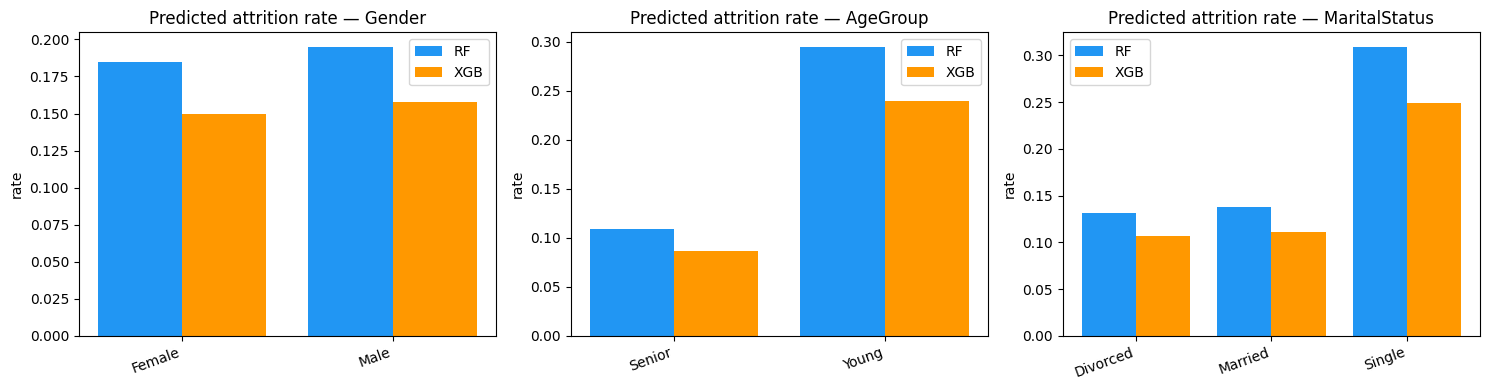

Level 1 done. Proceed to 05_counterfactual_fairness.ipynb


In [10]:
fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                         figsize=(5 * len(PROTECTED_ATTRIBUTES), 4))
for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
    rf_tbl  = prediction_fairness(rf_wrapper,  df_encoded, df_raw, feature_names, attr)
    xgb_tbl = prediction_fairness(xgb_wrapper, df_encoded, df_raw, feature_names, attr)
    x = np.arange(len(rf_tbl))
    ax.bar(x - 0.2, rf_tbl["pred_positive_rate"],  0.4, label="RF",  color="#2196F3")
    ax.bar(x + 0.2, xgb_tbl["pred_positive_rate"], 0.4, label="XGB", color="#FF9800")
    ax.set_xticks(x)
    ax.set_xticklabels(rf_tbl[attr], rotation=20, ha="right")
    ax.set_title(f"Predicted attrition rate — {attr}")
    ax.set_ylabel("rate")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PATHS["FAIRNESS"], "level1_prediction_fairness.png"), dpi=120)
plt.show()
print("Level 1 done. Proceed to 05_counterfactual_fairness.ipynb")

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# DIAGNOSTICA — validazione risultati notebook 04
# ─────────────────────────────────────────────────────────────────────────────
SEP = "=" * 65

# ── 1. DATASET ────────────────────────────────────────────────────────────────
print(SEP)
print("1. DATASET")
print(SEP)
print(f"  Totale dipendenti  : {len(df_raw)}")
print(f"  Feature usate      : {len(feature_names)}")
print(f"  Attrition reale    : {df_raw['Attrition'].sum()} / {len(df_raw)} ({df_raw['Attrition'].mean():.1%})")
print()
for attr in ['Gender', 'AgeGroup', 'MaritalStatus']:
    print(f"  {attr}:")
    print(df_raw[attr].value_counts().to_string())
    print()

# ── 2. MODELLI ────────────────────────────────────────────────────────────────
print(SEP)
print("2. SANITY CHECK MODELLI (threshold=0.20)")
print(SEP)
X_all  = df_encoded[feature_names].astype('float64')
y_true = df_raw['Attrition'].values

for name, wrapper in [('Random Forest', rf_wrapper), ('XGBoost', xgb_wrapper)]:
    proba = wrapper.predict_proba(X_all)[:, 1]
    pred  = (proba >= THRESHOLD).astype(int)
    tp = ((pred==1) & (y_true==1)).sum()
    fp = ((pred==1) & (y_true==0)).sum()
    fn = ((pred==0) & (y_true==1)).sum()
    print(f"  {name}:")
    print(f"    At-risk predetti : {pred.sum()} ({pred.mean():.1%})")
    print(f"    Recall           : {tp/(tp+fn):.1%}  |  Precision: {tp/(tp+fp):.1%}")
    print(f"    Proba media      : {proba.mean():.3f}  |  max: {proba.max():.3f}")
    print()

# ── 3. RECOURSE DATASET ───────────────────────────────────────────────────────
print(SEP)
print("3. RECOURSE DATASET")
print(SEP)
for name, rdf in [('Random Forest', recourse_rf), ('XGBoost', recourse_xgb)]:
    found = rdf['recourse_found'].sum()
    total = len(rdf)
    costs = rdf.loc[rdf['recourse_found'], 'L1_cost']
    print(f"  {name}:")
    print(f"    At-risk processati : {total}")
    print(f"    Recourse trovato   : {found} ({found/total:.1%})")
    print(f"    Costo L1 medio     : {costs.mean():.4f}  |  mediano: {costs.median():.4f}")
    print()

# ── 4. FACTS PREVIEW ─────────────────────────────────────────────────────────
print(SEP)
print("4. FACTS PREVIEW — gap di fairness sul recourse")
print(SEP)
for name, rdf in [('Random Forest', recourse_rf), ('XGBoost', recourse_xgb)]:
    print(f"  {name}:")
    for attr in ['Gender', 'AgeGroup', 'MaritalStatus']:
        rows = []
        for g in sorted(rdf[attr].dropna().unique()):
            sub  = rdf[rdf[attr] == g]
            eff  = sub['recourse_found'].mean()
            cost = sub.loc[sub['recourse_found'], 'L1_cost'].median()
            rows.append((g, len(sub), eff, cost))
        print(f"    {attr}:")
        for g, n, eff, cost in rows:
            print(f"      {str(g):15s} n={n:4d}  eff={eff:.1%}  median_cost={cost:.4f}")
        gap = round(max(r[2] for r in rows) - min(r[2] for r in rows), 3)
        print(f"      → GAP: {gap}  {'⚠️  unfair' if gap > 0.05 else '✅ ok'}")
    print()

# ── 5. FILE SALVATI ───────────────────────────────────────────────────────────
print(SEP)
print("5. FILE SALVATI")
print(SEP)
for fname in sorted(os.listdir(PATHS['FAIRNESS'])):
    fpath = os.path.join(PATHS['FAIRNESS'], fname)
    print(f"  ✅ {fname}  ({os.path.getsize(fpath):,} bytes)")

1. DATASET
  Totale dipendenti  : 1470
  Feature usate      : 30
  Attrition reale    : 237 / 1470 (16.1%)

  Gender:
Gender
Male      882
Female    588

  AgeGroup:
AgeGroup
Senior    819
Young     651

  MaritalStatus:
MaritalStatus
Married     673
Single      470
Divorced    327

2. SANITY CHECK MODELLI (threshold=0.20)
  Random Forest:
    At-risk predetti : 281 (19.1%)
    Recall           : 88.2%  |  Precision: 74.4%
    Proba media      : 0.156  |  max: 0.940

  XGBoost:
    At-risk predetti : 227 (15.4%)
    Recall           : 81.9%  |  Precision: 85.5%
    Proba media      : 0.148  |  max: 1.000

3. RECOURSE DATASET
  Random Forest:
    At-risk processati : 281
    Recourse trovato   : 281 (100.0%)
    Costo L1 medio     : 0.8437  |  mediano: 0.7824

  XGBoost:
    At-risk processati : 227
    Recourse trovato   : 225 (99.1%)
    Costo L1 medio     : 0.8266  |  mediano: 0.7528

4. FACTS PREVIEW — gap di fairness sul recourse
  Random Forest:
    Gender:
      Female          n